This notebook creates the central benchmark plot of the paper

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-deep")
plt.rcParams.update(
    {
        "text.usetex": True,  # Use LaTeX for text rendering
        "font.family": "serif",  # Use serif font
        "font.serif": ["Computer Modern Roman"],  # Use default LaTeX font
    }
)

In [8]:
df_lstm = pd.read_csv("../Results/lstm_hyper_opt.csv")
df_rnn = pd.read_csv("../Results/rnn_hyper_opt.csv")
df_vqc = pd.read_csv("../Results/vqc_hyper_opt.csv")
df_mlp = pd.read_csv("../Results/mlp_hyper_opt.csv")
df_qrnn = pd.read_csv("../Results/qrnn_paper_hyper_opt.csv")
df_qlstm_paper = pd.read_csv("../Results/qlstm_paper_hyper_opt.csv")
df_qlstm_le = pd.read_csv("../Results/qlstm_linear_enhanced_paper_hyper_opt.csv")

In [9]:
df_vqc_reuploading_expencnorm = df_vqc[df_vqc["Ansatz"].str.startswith("ruexp_")]
df_vqc_dressed = df_vqc[df_vqc["Ansatz"].str.startswith("paper_rivera-ruiz_with_inputlayer_")]
df_qrnn_reset = df_qrnn[df_qrnn["Ansatz"] == "paper_reset"]
df_qrnn_no_reset = df_qrnn[df_qrnn["Ansatz"] == "paper_no_reset"]

In [10]:
def find_best(df):
    df_intern = df.copy()
    best_rows = df_intern.loc[
        df_intern.groupby(["Prediction Step", "Data", "Sequence Length"], observed=True)[
            "MSE Validation Median"
        ].idxmin()
    ]
    return best_rows


best_lstm = find_best(df_lstm)
best_vqc_reuploading_expencnorm = find_best(df_vqc_reuploading_expencnorm)
best_vqc_dressed = find_best(df_vqc_dressed)
best_mlp = find_best(df_mlp)
best_qrnn_reset = find_best(df_qrnn_reset)
best_qrnn_no_reset = find_best(df_qrnn_no_reset)
best_qlstm_paper = find_best(df_qlstm_paper)
best_rnn = find_best(df_rnn)
best_qlstm_le = find_best(df_qlstm_le)

In [11]:
sequence_lengths = [4, 8, 16]
prediction_steps_mackey = [1, 70, 140]
prediction_steps_henon = [1, 2, 4]
prediction_steps_lorenz = [1, 13, 25]
models = {
    "d-QNN": (best_vqc_dressed, "#D65A31"),
    "ru-QNN": (best_vqc_reuploading_expencnorm, "#E27D60"),
    "QRNN": (best_qrnn_no_reset, "#FFBF46"),
    "QLSTM": (best_qlstm_paper, "#C5A880"),
    "le-QLSTM": (best_qlstm_le, "#6B4226"),
    "MLP": (best_mlp, "#006D77"),
    "RNN": (best_rnn, "#00A8CC"),
    "LSTM": (best_lstm, "#4A90E2"),
}
["#B0A86E", "#9467BD"]
data = {
    "mackey_1000": (prediction_steps_mackey, "Mackey-Glass"),
    "henon_1000": (prediction_steps_henon, "Hénon"),
    "lorenz_1000": (prediction_steps_lorenz, "Lorenz"),
}
seq_map = {4: "d", 8: "X", 16: "o"}

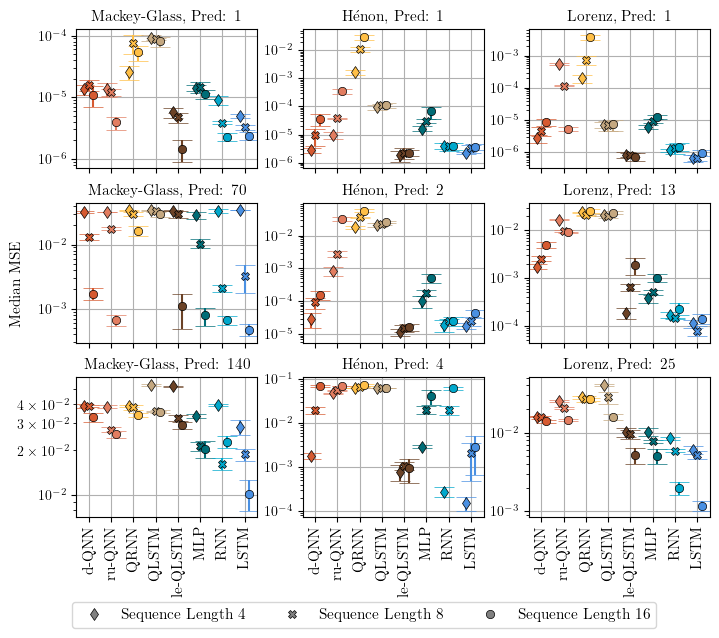

In [12]:
fig, axs = plt.subplots(
    len(prediction_steps_mackey),
    len(data),
    figsize=(len(data) * 2.4, len(prediction_steps_mackey) * 2.1),
    sharex=False,
)
for i, (model, (df, color)) in enumerate(models.items()):
    for j, (data_label, (prediction_steps, data_title)) in enumerate(data.items()):
        for k, prediction_step in enumerate(prediction_steps):
            ax = axs[k, j]
            df_filtered = df[
                (df["Data"] == data_label) & (df["Prediction Step"] == prediction_step)
            ]
            df_filtered = df_filtered.sort_values("Sequence Length")
            if not df_filtered.empty:
                for l, seq_len in enumerate(sequence_lengths):
                    df_seq_len = df_filtered[df_filtered["Sequence Length"] == seq_len]
                    x_positions = [i + (l - 1) * 0.2] * len(df_seq_len)
                    ax.errorbar(
                        x_positions,
                        df_seq_len["MSE Testing Median"],
                        yerr=df_seq_len["MSE Testing Mad"],
                        marker=seq_map[seq_len],
                        label=model,
                        color=color,
                        capsize=7,
                        markeredgecolor="black",
                        markeredgewidth=0.5,
                    )
            ax.set_yscale("log")
            ax.set_title(f"{data_title}, Pred: {prediction_step}", fontsize=11)
            ax.set_xticks(list(range(0, len(models))))
            if k == 2:
                ax.set_xticklabels(list(models.keys()), fontsize=11)
                ax.tick_params(axis="x", rotation=90)
            else:
                ax.set_xticks(range(len(models)))  # Keep x-ticks for grid alignment
                ax.set_xticklabels([""] * len(models))  # Set empty labels to hide x-tick text
            ax.grid(True)
custom_handles = [
    ax.plot(
        [],
        [],
        marker=seq_map[seq_length],
        linestyle="None",
        color="gray",
        label=f"Sequence Length {seq_length}",
        markeredgecolor="black",
        markeredgewidth=0.5,
    )[0]
    for seq_length in seq_map
]
# fig.suptitle('Best Median MSE for each Model', fontsize=14)
# Create custom legend
fig.legend(
    custom_handles,
    [f"Sequence Length {seq_length}" for seq_length in seq_map],
    loc="lower center",
    ncol=3,
    bbox_to_anchor=(0.5, 0.0016),
    fontsize=11,
)

# fig.text(0.54, 0.09, 'Sequence Length', ha='center')
fig.text(0.008, 0.56, "Median MSE", va="center", rotation="vertical", fontsize=11)

plt.tight_layout()  # Adjust layout to accommodate the legend outside
fig.subplots_adjust(left=0.1, right=0.98, top=0.965, bottom=0.19, wspace=0.25, hspace=0.25)
plt.savefig(f"all_models_mse_over_model_all_ruopt.pdf")